# Impact of LS cocktail on TDCR detection efficiency

Compares **12 commercial LS cocktails** available in TDCRPy for three nuclides:

| Nuclide | Decay | Key physics |
|---------|-------|-------------|
| **H-3** | Pure β⁻, 18.6 keV | Low-energy quenching |
| **C-14** | Pure β⁻, 156 keV | Medium-energy quenching |
| **Fe-55** | EC + Mn Kα X-rays, 5.9 keV | Photoelectric interaction (sensitive to heavy elements P, S, Na, Cl) |

All runs use the **stochastic model** (N = 2000) for consistency across nuclide types.
Reference cocktail: **Ultima Gold** (solid bars; all residuals relative to it).

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm
from importlib.metadata import version
warnings.filterwarnings('ignore')
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.12


## ⚙️ Configuration

In [3]:
L   = 5.0       # free parameter (photons keV⁻¹)
kB  = 1.0e-5    # Birks constant (cm keV⁻¹)
V   = 10        # scintillator volume (mL)
N   = 2000      # Monte-Carlo trials per run

NUCLIDES = ['H-3', 'C-14', 'Fe-55']
NUC_COL  = ['#1f77b4', '#2ca02c', '#e67e22']
REF      = 'Ultima Gold'

# Commercial cocktails to compare (pure cocktail, no aqueous fraction)
COCKTAILS = [
    'Ultima Gold',
    'Ultima Gold XR',
    'Ultima Gold AB',
    'Ultima Gold LLT',
    'Insta-Gel Plus',
    'Hionic-Fluor',
    'ProSafe+',
    'ProSafe HC+',
    'Pico-Fluor 40',
    'Pico-Fluor Plus',
    'Aqualight Beta',
    'Permafluor E+',
]

print(f'L={L} photons/keV  kB={kB} cm/keV  V={V} mL  N={N}')
print(f'{len(COCKTAILS)} cocktails × {len(NUCLIDES)} nuclides = {len(COCKTAILS)*len(NUCLIDES)} runs')

L=5.0 photons/keV  kB=1e-05 cm/keV  V=10 mL  N=2000
12 cocktails × 3 nuclides = 36 runs


## 1. Cocktail properties

In [4]:
props = {}
print(f'{"Cocktail":<30} {"rho":>6}  {"Z":>6}  {"A":>6}  {"Z/A":>6}  {"P+S+Na+Cl (%)"}' )
print('─' * 80)
for name in COCKTAILS:
    tl.modifyLScocktail(name, 0.0, 'Water', 0.0)
    tl = importlib.reload(tl)
    Z = tl.Z; A = tl.A; rho = tl.RHO
    heavy = (tl.pP + tl.pS + tl.pNa + tl.pCl) * 100  # atomic % heavy elements
    props[name] = {'Z': Z, 'A': A, 'rho': rho, 'heavy': heavy}
    print(f'{name:<30} {rho:6.4f}  {Z:6.4f}  {A:6.4f}  {Z/A:6.4f}  {heavy:6.3f}')

# Restore
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)

Cocktail                          rho       Z       A     Z/A  P+S+Na+Cl (%)
────────────────────────────────────────────────────────────────────────────────
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time =

Ultima Gold                    0.9800  3.2516  5.9449  0.5469   0.348
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold XR
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.99 g/cm3
	Z = 3.2146, A = 5.8553
	Atomic fraction: H=0.5851, C=0.3554, N=0.0007, O=0.0555
	                 P=0.0022, S=0.0006, Na=0.0006, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold XR                 0.9900  3.2146  5.8553  0.5490   0.332
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold AB
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2382, A = 5.9121
	Atomic fraction: H=0.5732, C=0.3755, N=0.0002, O=0.0509
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold AB                 0.9800  3.2382  5.9121  0.5477   0.021
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold LLT
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2381, A = 5.9115
	Atomic fraction: H=0.5735, C=0.3745, N=0.0002, O=0.0516
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold LLT                0.9800  3.2381  5.9115  0.5478   0.021
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Insta-Gel Plus
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.9500000000000001 g/cm3
	Z = 3.2483, A = 5.9253
	Atomic fraction: H=0.5796, C=0.3471, N=0.0001, O=0.0731
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


...

ProSafe HC+                    0.9600  3.2291  5.8940  0.5479   0.019
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Pico-Fluor 40
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.9100000000000001 g/cm3
	Z = 3.2504, A = 5.9326
	Atomic fraction: H=0.5768, C=0.3556, N=0.0008, O=0.0667
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Pico-Fluor 40                  0.9100  3.2504  5.9326  0.5479   0.000
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Pico-Fluor Plus
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.96 g/cm3
	Z = 3.1979, A = 5.8266
	Atomic fraction: H=0.5780, C=0.3784, N=0.0004, O=0.0430
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Pico-Fluor Plus                0.9600  3.1979  5.8266  0.5488   0.019
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Aqualight Beta
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.96 g/cm3
	Z = 3.2412, A = 5.9167
	Atomic fraction: H=0.5752, C=0.3695, N=0.0000, O=0.0544
	                 P=0.0010, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Aqualight Beta                 0.9600  3.2412  5.9167  0.5478   0.096
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Permafluor E+
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.8999999999999999 g/cm3
	Z = 3.1405, A = 5.7106
	Atomic fraction: H=0.5795, C=0.4015, N=0.0000, O=0.0190
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Permafluor E+                  0.9000  3.1405  5.7106  0.5499   0.000
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


## 2. Efficiency scan — stochastic model

In [5]:
# results[cocktail][nuclide] = {'eff_S':, 'u_S':, 'eff_D':, 'u_D':, 'eff_T':, 'u_T':}
results = {c: {} for c in COCKTAILS}

for name in COCKTAILS:
    tl.modifyLScocktail(name, 0.0, 'Water', 0.0)
    tl = importlib.reload(tl)
    import tdcrpy.TDCRPy as tm   # reload TDCRPy to pick up fresh config
    tm = importlib.reload(tm)

    print(f'\n{name}')
    for rad in NUCLIDES:
        r = tm.TDCRPy(L, rad, '1', N, kB, V)
        results[name][rad] = {
            'eff_S': r[0], 'u_S': r[1],
            'eff_D': r[2], 'u_D': r[3],
            'eff_T': r[4], 'u_T': r[5],
        }
        print(f'  {rad:<6}  eff_D={r[2]:.5f}±{r[3]:.5f}  eff_T={r[4]:.5f}±{r[5]:.5f}')

# Restore defaults
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
print('\nDone.')

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Ultima Gold


  H-3     eff_D=0.64719±0.00775  eff_T=0.39210±0.00737
  C-14    eff_D=0.95716±0.00377  eff_T=0.91914±0.00507


  Fe-55   eff_D=0.74416±0.00641  eff_T=0.38395±0.00343
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold XR
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.99 g/cm3
	Z = 3.2146, A = 5.8553
	Atomic fraction: H=0.5851, C=0.3554, N=0.0007, O=0.0555
	                 P=0.0022, S=0.0006, Na=0.0006, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Ultima Gold XR


...


Permafluor E+


  H-3     eff_D=0.64054±0.00788  eff_T=0.39204±0.00749


  C-14    eff_D=0.95798±0.00375  eff_T=0.92171±0.00502


  Fe-55   eff_D=0.75556±0.00618  eff_T=0.39169±0.00332
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Done.


## 3. Efficiency comparison — split by nuclide

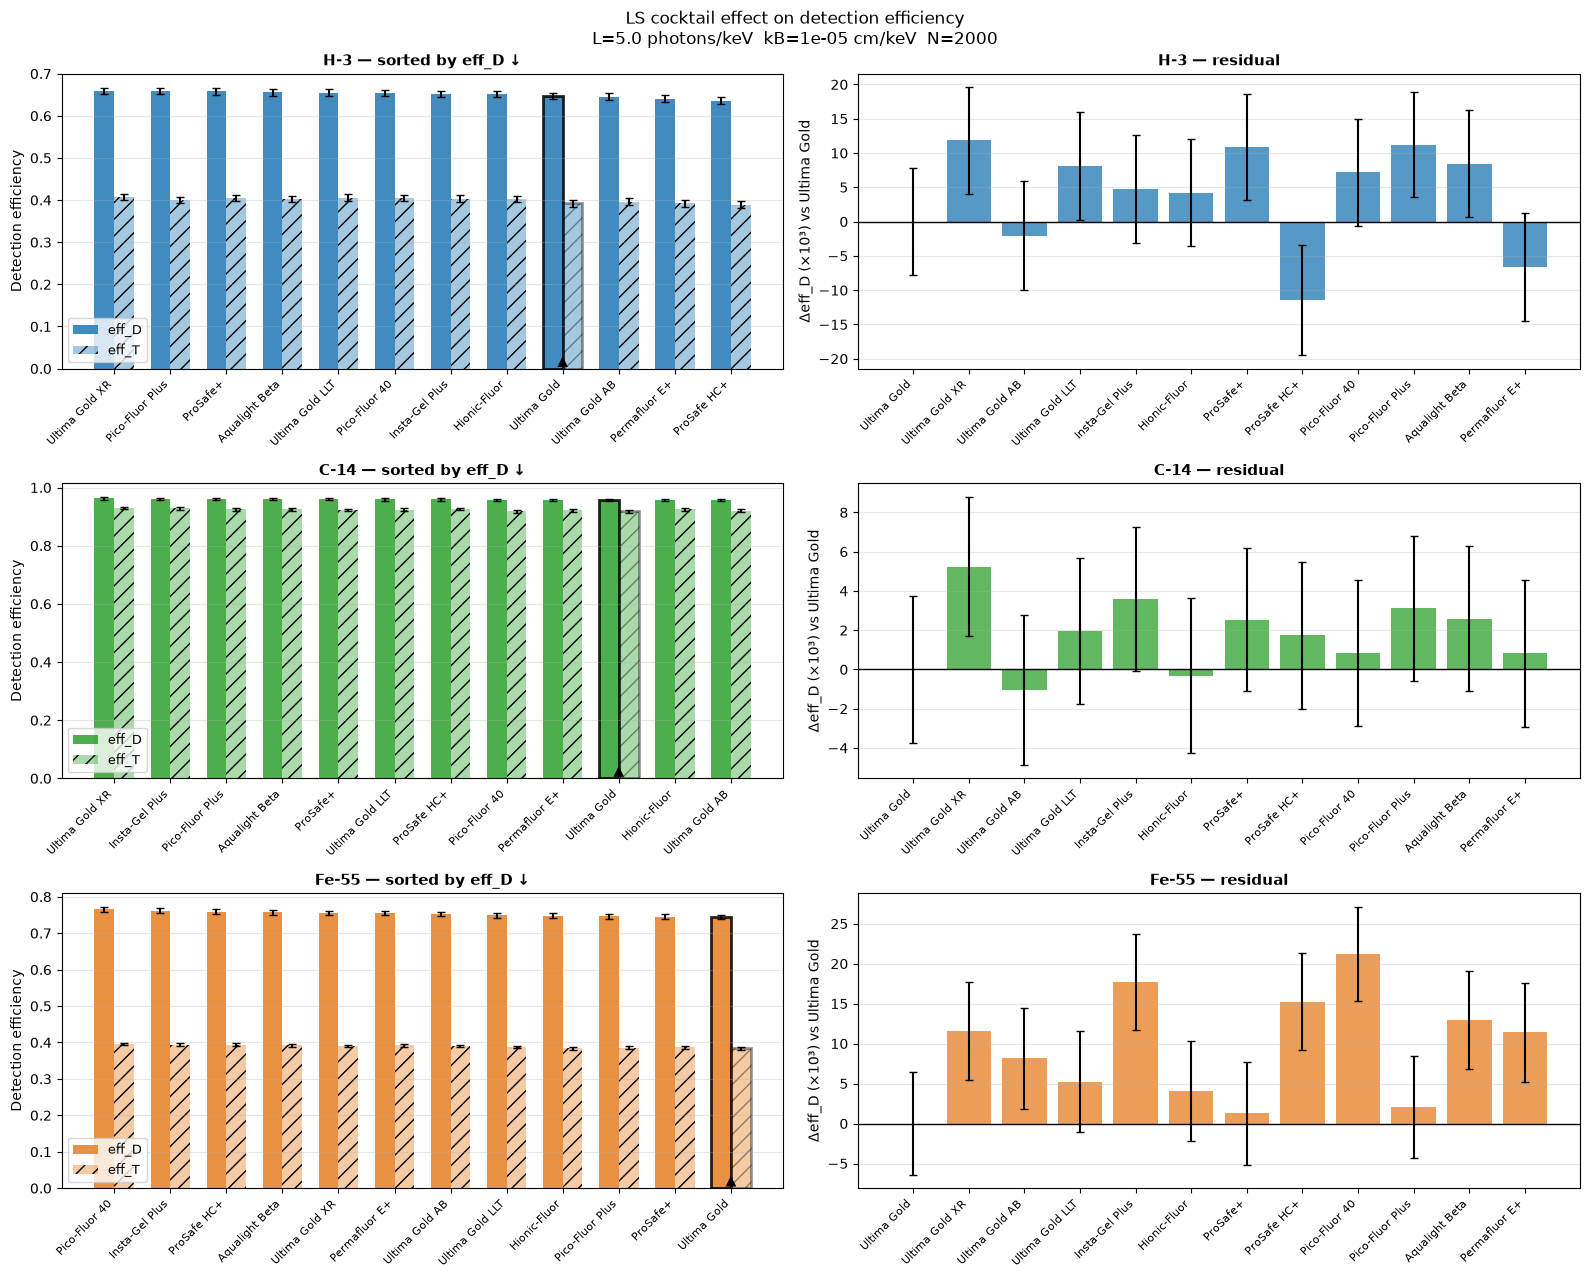

Figure saved.


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle(f'LS cocktail effect on detection efficiency\nL={L} photons/keV  kB={kB} cm/keV  N={N}',
             fontsize=12)

n_c = len(COCKTAILS)
x   = np.arange(n_c)
w   = 0.35
ref_idx = COCKTAILS.index(REF)

for row, (rad, col) in enumerate(zip(NUCLIDES, NUC_COL)):
    eff_D = np.array([results[c][rad]['eff_D'] for c in COCKTAILS])
    u_D   = np.array([results[c][rad]['u_D']   for c in COCKTAILS])
    eff_T = np.array([results[c][rad]['eff_T'] for c in COCKTAILS])
    u_T   = np.array([results[c][rad]['u_T']   for c in COCKTAILS])

    # Sort by eff_D descending
    order  = np.argsort(eff_D)[::-1]
    c_sort = [COCKTAILS[i] for i in order]
    dD_s = eff_D[order]; uD_s = u_D[order]
    dT_s = eff_T[order]; uT_s = u_T[order]
    ref_pos = c_sort.index(REF)

    # Panel left: eff_D and eff_T bars
    ax = axes[row, 0]
    bars_D = ax.bar(x - w/2, dD_s, w, yerr=uD_s, capsize=3,
                    color=col, alpha=0.85, label='eff_D')
    bars_T = ax.bar(x + w/2, dT_s, w, yerr=uT_s, capsize=3,
                    color=col, alpha=0.4, hatch='//', label='eff_T')
    # Highlight reference
    bars_D[ref_pos].set_edgecolor('black'); bars_D[ref_pos].set_linewidth(2)
    bars_T[ref_pos].set_edgecolor('black'); bars_T[ref_pos].set_linewidth(2)
    ax.set_xticks(x)
    ax.set_xticklabels(c_sort, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Detection efficiency', fontsize=10)
    ax.set_title(f'{rad} — sorted by eff_D ↓', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.text(ref_pos, ax.get_ylim()[0], '▲', ha='center', va='bottom',
            color='black', fontsize=10, fontweight='bold')

    # Panel right: residual vs REF (×10³)
    ax = axes[row, 1]
    ref_D = results[REF][rad]['eff_D']
    resid = (eff_D - ref_D) * 1e3   # ×10³
    ures  = u_D * 1e3
    colors_r = [col if i != ref_idx else 'gray' for i in range(n_c)]
    ax.axhline(0, color='black', lw=1)
    ax.bar(x, resid, color=colors_r, alpha=0.75, yerr=ures, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(COCKTAILS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(f'Δeff_D (×10³) vs {REF}', fontsize=10)
    ax.set_title(f'{rad} — residual', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4. Cocktail physical properties

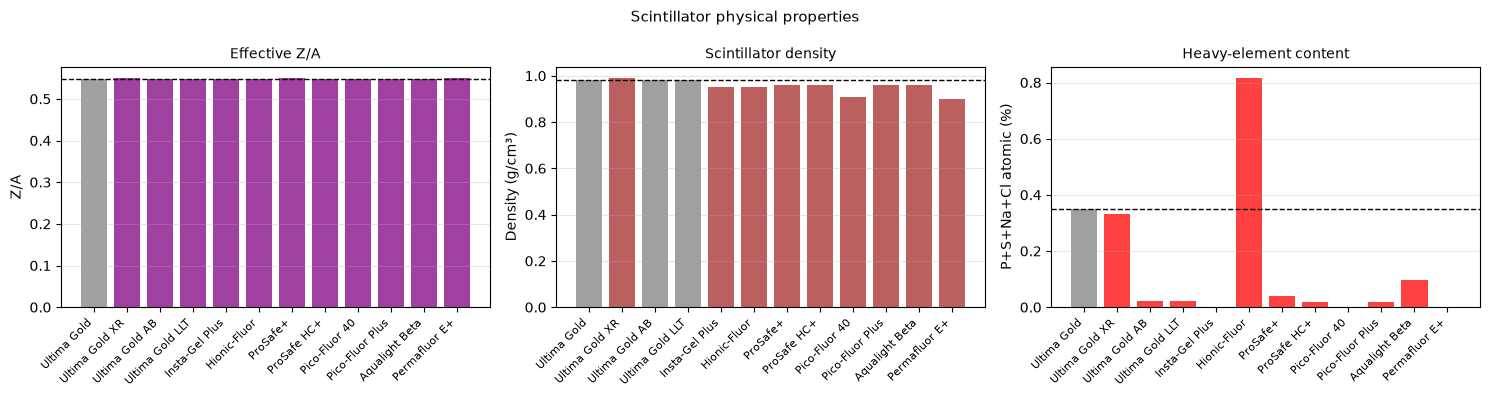

Figure saved.


In [7]:
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Scintillator physical properties', fontsize=11)

ZA   = [props[c]['Z'] / props[c]['A']   for c in COCKTAILS]
rhos = [props[c]['rho']                  for c in COCKTAILS]
hvy  = [props[c]['heavy']               for c in COCKTAILS]

for ax, vals, ylabel, title, color in [
    (axes2[0], ZA,   'Z/A',                   'Effective Z/A',            'purple'),
    (axes2[1], rhos, 'Density (g/cm³)',        'Scintillator density',     'brown'),
    (axes2[2], hvy,  'P+S+Na+Cl atomic (%)',   'Heavy-element content',    'red'),
]:
    ref_val = vals[COCKTAILS.index(REF)]
    bar_c = [color if v != ref_val else 'gray' for v in vals]
    ax.bar(np.arange(len(COCKTAILS)), vals, color=bar_c, alpha=0.75)
    ax.axhline(ref_val, color='black', lw=1, ls='--')
    ax.set_xticks(np.arange(len(COCKTAILS)))
    ax.set_xticklabels(COCKTAILS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_properties.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Correlation: efficiency vs cocktail properties

For pure β emitters (H-3, C-14) quenching depends on Z/A and density.
For Fe-55 (EC + X-ray) the photoelectric cross-section at 5.9 keV
is higher for heavy elements (P, S, Na, Cl with Z > 8), so cocktails
rich in these elements may show a different response.

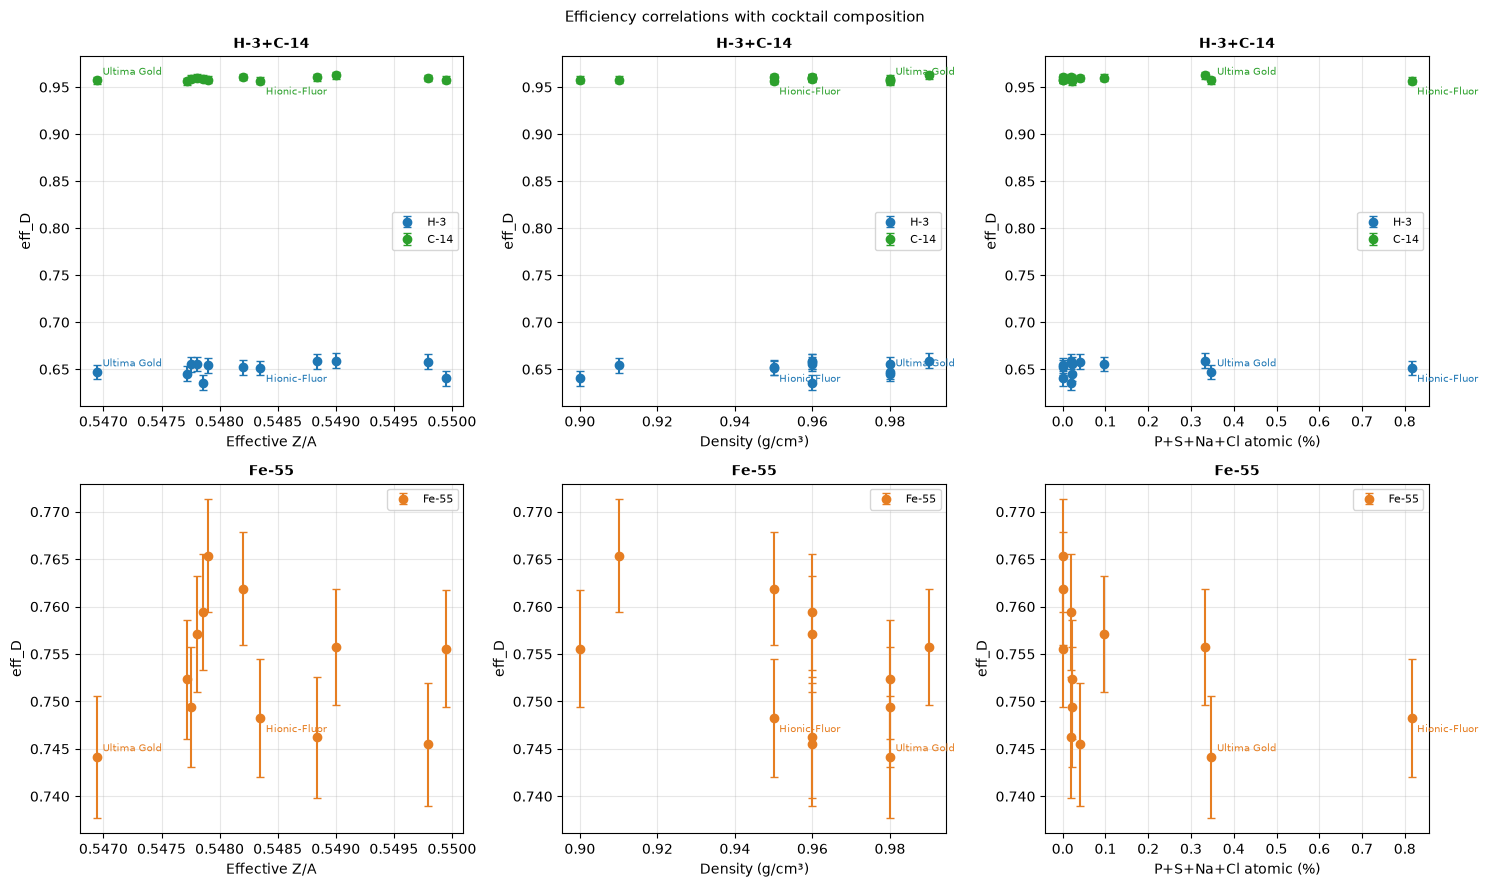

Figure saved.


In [8]:
fig3, axes3 = plt.subplots(2, 3, figsize=(15, 9))
fig3.suptitle('Efficiency correlations with cocktail composition', fontsize=11)

x_vars = [
    ('Z/A',        [props[c]['Z']/props[c]['A'] for c in COCKTAILS], 'Effective Z/A'),
    ('density',    [props[c]['rho']             for c in COCKTAILS], 'Density (g/cm³)'),
    ('heavy',      [props[c]['heavy']           for c in COCKTAILS], 'P+S+Na+Cl atomic (%)'),
]

for col_ax, (xkey, xvals, xlabel) in enumerate(x_vars):
    for row_ax, (rad, col) in enumerate([(('H-3','C-14'), NUC_COL[:2]), (('Fe-55',), [NUC_COL[2]])]):
        ax = axes3[row_ax, col_ax]
        for r, c in zip(rad, col):
            yvals = [results[name][r]['eff_D'] for name in COCKTAILS]
            yerrs = [results[name][r]['u_D']   for name in COCKTAILS]
            ax.errorbar(xvals, yvals, yerr=yerrs, fmt='o', color=c, capsize=3,
                        markersize=6, label=r)
            # Label the reference
            idx_ref = COCKTAILS.index(REF)
            ax.annotate(REF, (xvals[idx_ref], yvals[idx_ref]),
                        textcoords='offset points', xytext=(4, 4), fontsize=7, color=c)
            # Label Hionic-Fluor (high P)
            idx_h = COCKTAILS.index('Hionic-Fluor')
            ax.annotate('Hionic-Fluor', (xvals[idx_h], yvals[idx_h]),
                        textcoords='offset points', xytext=(4, -10), fontsize=7, color=c)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('eff_D', fontsize=10)
        ax.set_title('+'.join(rad), fontsize=10, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6. Summary table

In [9]:
print(f'{"Cocktail":<30} {"rho":>6}  {"Z/A":>6}  {"heavy":>6}  '
      f'{"H-3 eff_D":>11}  {"C-14 eff_D":>11}  {"Fe-55 eff_D":>12}')
print('─' * 100)

# Sort by Fe-55 eff_D
sorted_c = sorted(COCKTAILS, key=lambda c: results[c]['Fe-55']['eff_D'], reverse=True)

for name in sorted_c:
    p = props[name]
    dH  = results[name]['H-3']['eff_D'];  uH  = results[name]['H-3']['u_D']
    dC  = results[name]['C-14']['eff_D']; uC  = results[name]['C-14']['u_D']
    dFe = results[name]['Fe-55']['eff_D']; uFe = results[name]['Fe-55']['u_D']
    marker = ' ←' if name == REF else ''
    print(f'{name:<30} {p["rho"]:6.4f}  {p["Z"]/p["A"]:6.4f}  {p["heavy"]:6.3f}  '
          f'{dH:7.5f}±{uH:.5f}  {dC:7.5f}±{uC:.5f}  {dFe:8.5f}±{uFe:.5f}{marker}')

Cocktail                          rho     Z/A   heavy    H-3 eff_D   C-14 eff_D   Fe-55 eff_D
────────────────────────────────────────────────────────────────────────────────────────────────────
Pico-Fluor 40                  0.9100  0.5479   0.000  0.65435±0.00784  0.95800±0.00370   0.76539±0.00591
Insta-Gel Plus                 0.9500  0.5482   0.000  0.65192±0.00789  0.96076±0.00366   0.76189±0.00599
ProSafe HC+                    0.9600  0.5479   0.019  0.63571±0.00800  0.95890±0.00374   0.75943±0.00609
Aqualight Beta                 0.9600  0.5478   0.096  0.65565±0.00778  0.95975±0.00369   0.75711±0.00612
Ultima Gold XR                 0.9900  0.5490   0.332  0.65902±0.00779  0.96240±0.00355   0.75575±0.00612
Permafluor E+                  0.9000  0.5499   0.000  0.64054±0.00788  0.95798±0.00375   0.75556±0.00618
Ultima Gold AB                 0.9800  0.5477   0.021  0.64510±0.00794  0.95611±0.00381   0.75231±0.00627
Ultima Gold LLT                0.9800  0.5478   0.021  0.65526±